# Raw ERSP Clustering
210_raw_clustering.ipynb


K-Means + Hierarchical (Ward) clustering on raw flattened ERSP matrices (300×128 → 38400 features).

Outputs land in `outputs/clustering/{kmeans,hierarchical}/raw/runs/<timestamp>/` via `lf_cluster_run.fit_and_save`.
Each run writes: model.joblib, predictor.joblib, X_train.npy, labels.csv, metrics.json, manifest.json, plus standard figures (centroids, silhouette per cluster, similarity heatmap, centroid distance heatmap).


In [1]:
## 0. Config & imports
import os
from pathlib import Path
import datetime
import json

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt  # for optional plots (no seaborn)

# ---- Identity / tags ----
SCRIPT_NAME = "210_raw_clustering.ipynb"
ALGO_TAG = "kmeans_raw"
RUN_ID = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")  # e.g. 20251117_112233

# ---- Paths ----
ANALYSIS_ROOT = Path(r"\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda")

# Input: RAWONLY ERSP matrices
INPUT_DIR = ANALYSIS_ROOT / r"01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY"

# Output: clustering results & figures
CLUSTERING_OUTPUT_DIR  = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/clustering/kmeans"
FIGURES_EMBEDDINGS_DIR = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/figures/embeddings"
FIGURES_ERSP_DIR       = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/figures/ersp_clusters"
LOG_DIR                = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/logs"

for d in [CLUSTERING_OUTPUT_DIR, FIGURES_EMBEDDINGS_DIR, FIGURES_ERSP_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)


# WM electrodes for double check    
# ---- WM reference maps (unchanged data, compact helpers) ----



# ---- Data shape constants ----
N_TIME = 300
N_FREQ = 129
N_FEATURES = N_TIME * N_FREQ

# ---- Clustering parameters ----
N_CLUSTERS = 13
RANDOM_STATE = 42

print("SCRIPT_NAME:", SCRIPT_NAME)
print("ALGO_TAG   :", ALGO_TAG)
print("RUN_ID     :", RUN_ID)
print("Input dir  :", INPUT_DIR)


## Auto-detect patient IDs from outputs/04_ersp_LM_RAWONLY

from pathlib import Path

# Patient folders = all directories inside INPUT_DIR
PATIENT_IDS = sorted([d.name for d in INPUT_DIR.iterdir() if d.is_dir()])

print("Detected patient folders:")
for p in PATIENT_IDS:
    print("  -", p)

print("\nTotal patients detected:", len(PATIENT_IDS))


SCRIPT_NAME: 210_raw_clustering.ipynb
ALGO_TAG   : kmeans_raw
RUN_ID     : 20260504_221648
Input dir  : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY
Detected patient folders:
  - EL030
  - EL035
  - EL036
  - EL037
  - EL038
  - EL040
  - EL042
  - EL043
  - EL045
  - PAT_2868
  - PAT_3066
  - PAT_3301
  - PAT_3390
  - PAT_3415
  - PAT_3455
  - PAT_3780
  - PAT_3965
  - PAT_3975

Total patients detected: 18


In [2]:
## 2. Helper: parse electrode name from filename

def parse_electrode_from_filename(fname: str) -> str:
    """
    Example filename:
        PAT_3301_picture_None_ERSP_AG2_TN.npy
    We want to extract 'AG2' as electrode name.
    """
    name = Path(fname).name
    # Split on '_ERSP_' first
    if "_ERSP_" in name:
        left, right = name.split("_ERSP_", 1)
        # right is like "AG2_TN.npy"
        # remove suffix and trailing parts after electrode
        right_no_ext = right.rsplit(".", 1)[0]  # remove .npy
        # Typically pattern is "<electrode>_TN" or similar
        electrode = right_no_ext.split("_")[0]
        return electrode
    else:
        # fallback: no ERSP marker, just strip extension
        return name.rsplit(".", 1)[0]


In [3]:
## 3. Load ERSP matrices and metadata from ALL discovered patients AND ALL their conditions

TASK = "LM"   # keep this as before

ersp_list = []
meta_rows = []

for pat in PATIENT_IDS:
    patient_dir = INPUT_DIR / pat / TASK / "ERSP_matrix"
    if not patient_dir.exists():
        print(f"[WARN] Missing ERSP_matrix folder for patient {pat}: {patient_dir}")
        continue

    # Find all condition folders inside ERSP_matrix
    condition_dirs = [d for d in patient_dir.iterdir() if d.is_dir()]

    if not condition_dirs:
        print(f"[WARN] No condition subfolders for {pat} in {patient_dir}")
        continue

    print(f"\nPatient {pat} — conditions found:", [d.name for d in condition_dirs])

    for cond_dir in condition_dirs:
        cond_name = cond_dir.name
        npy_files = sorted(cond_dir.glob("*.npy"))

        if not npy_files:
            print(f"[WARN] No .npy files found in {cond_dir}")
            continue

        print(f"  Loading {len(npy_files)} files from condition '{cond_name}'")

        for fpath in npy_files:
            arr = np.load(fpath)

            if arr.shape != (N_FREQ,N_TIME):
                print(f"  [WARN] Incorrect shape {arr.shape} in {fpath}, skipping.")
                continue

            ersp_list.append(arr)

            meta_rows.append({
                "patient_id": pat,
                "condition": cond_name,
                "task": TASK,
                "electrode": parse_electrode_from_filename(fpath.name),
                "file_path": str(fpath),
            })

df_meta = pd.DataFrame(meta_rows)
df_meta.index.name = "sample_idx"
df_meta.reset_index(inplace=True)

print("\n=== Finished Loading ===")
print("Total ERSP samples loaded:", len(ersp_list))


Patient EL030 — conditions found: ['audio', 'picture', 'reading']
  Loading 89 files from condition 'audio'
  Loading 89 files from condition 'picture'
  Loading 89 files from condition 'reading'

Patient EL035 — conditions found: ['audio', 'picture', 'reading']
  Loading 118 files from condition 'audio'
  Loading 118 files from condition 'picture'
  Loading 118 files from condition 'reading'

Patient EL036 — conditions found: ['audio', 'picture', 'reading']
  Loading 63 files from condition 'audio'
  Loading 63 files from condition 'picture'
  Loading 63 files from condition 'reading'

Patient EL037 — conditions found: ['audio', 'picture', 'reading']
  Loading 115 files from condition 'audio'
  Loading 115 files from condition 'picture'
  Loading 115 files from condition 'reading'

Patient EL038 — conditions found: ['audio', 'picture', 'reading']
  Loading 84 files from condition 'audio'
  Loading 84 files from condition 'picture'
  Loading 84 files from condition 'reading'

Patient 

In [4]:
## 4. Exclude non-neural channels (PHOTO, X*, E*, ECG, AUDIO, markers, +/-) and WM refs

import re
import numpy as np
import pandas as pd

# ---- 4.1 Helper: non-neural / aux channel name filter ----

def is_non_neural_electrode(label: str) -> bool:
    """
    Returns True if the electrode name looks like:
    - PHOTO / photo
    - MRK / MKR
    - ECG
    - AUDIO
    - X1..X8, E1..E8, X
    - contains '+' or '-'
    Case-insensitive.
    """
    if label is None:
        return False
    s = str(label).strip()
    s_up = s.upper()

    # Any + or - in the name -> drop
    if "+" in s_up or "-" in s_up:
        return True

    # Direct tokens
    direct_tokens = ["PHOTO", "MRK", "MKR", "ECG", "AUDIO"]
    if any(tok in s_up for tok in direct_tokens):
        return True

    # Exactly X
    if s_up == "X":
        return True

    # Exactly X1..X8 or E1..E8
    if re.fullmatch(r"[XE][1-8]", s_up):
        return True

    return False

# ---- 4.2 Build WM-ref electrode sets per patient ----
# WHITE_MATTER_REFS_NUMS must already be defined in your config cell.

WM_REF_SET = {}
for pat, grids in WHITE_MATTER_REFS_NUMS.items():
    names = set()
    for prefix, nums in grids.items():
        for num in nums:
            names.add(f"{prefix}{num}".upper())
    WM_REF_SET[pat] = names

# ---- 4.3 Masks: non-neural + WM-ref ----

# Non-neural mask based on name
non_neural_mask = df_meta["electrode"].apply(is_non_neural_electrode)

# WM-ref mask based on patient + electrode name
def is_wm_ref(row):
    pat = row["patient_id"]
    label = str(row["electrode"]).upper()
    if pat not in WM_REF_SET:
        return False
    return label in WM_REF_SET[pat]

wm_ref_mask = df_meta.apply(is_wm_ref, axis=1)

exclude_mask = non_neural_mask | wm_ref_mask
keep_mask = ~exclude_mask

print(f"Total samples before exclusion: {len(df_meta)}")
print(f"  Non-neural channels to exclude: {non_neural_mask.sum()}")
print(f"  WM-ref channels to exclude:     {wm_ref_mask.sum()}")
print(f"  Total excluded:                  {exclude_mask.sum()}")
print(f"  Remaining for clustering:        {keep_mask.sum()}")

# ---- 4.4 Show what is being excluded ----
excluded_df = df_meta[exclude_mask].copy()
print("\nExamples of excluded electrodes:")
display(
    excluded_df[["patient_id", "electrode", "condition"]]
    .sort_values(["patient_id", "electrode"])
    .head(50)
)

# ---- 4.5 Apply exclusion to df_meta and ersp_list ----
# sample_idx is the original index used when building ersp_list

bad_sample_idxs = df_meta.loc[exclude_mask, "sample_idx"].to_numpy()
keep_sample_idxs = df_meta.loc[keep_mask, "sample_idx"].to_numpy()

# Rebuild ersp_list in the new order (only kept indices)
ersp_list = [ersp_list[i] for i in keep_sample_idxs]

# Filter df_meta and reset index
df_meta = df_meta[keep_mask].reset_index(drop=True)

print("\nAfter exclusion:")
print("  df_meta rows:", len(df_meta))
print("  ersp_list len:", len(ersp_list))


Total samples before exclusion: 6097
  Non-neural channels to exclude: 0
  WM-ref channels to exclude:     0
  Total excluded:                  0
  Remaining for clustering:        6097

Examples of excluded electrodes:


,patient_id,electrode,condition



After exclusion:
  df_meta rows: 6097
  ersp_list len: 6097


Positive threshold: value > 2.2, high if prop ≥ 0.02
Negative threshold: value < -3, high if prop ≥ 0.04
High-activity electrodes: 1410
Normal/low electrodes:    4687

Example high-activity electrodes:


,patient_id,electrode,condition,prop_above_pos,prop_below_neg
2360,EL045,A,audio,0.337442,0.076925
2372,EL045,A,audio,0.313850,0.096331
623,EL036,A,audio,0.288889,0.020413
2359,EL045,A,audio,0.273928,0.056770
749,EL036,A,reading,0.271964,0.049432
3911,PAT_3415,OS1,picture,0.267829,0.000775
2449,EL045,A,picture,0.265323,0.144703
622,EL036,A,audio,0.255969,0.004083
2107,EL043,iSMG,audio,0.254470,0.009302
789,EL036,pfc,reading,0.252248,0.019044



Example normal/low electrodes:


,patient_id,electrode,condition,prop_above_pos,prop_below_neg
6007,PAT_3975,HAG10,reading,0.000258,0.029509
573,EL035,Fopc,reading,0.000543,0.006899
6015,PAT_3975,HAG9,reading,0.000543,0.018889
916,EL037,pI,audio,0.000594,0.004212
3034,PAT_3066,IMG1,picture,0.000620,0.001499
6008,PAT_3975,HAG11,reading,0.000620,0.022584
1926,EL042,aH,picture,0.000646,0.002739
6058,PAT_3975,IMG16,reading,0.000698,0.036925
4269,PAT_3455,HPD8,reading,0.000724,0.027726
5975,PAT_3975,CPG15,reading,0.000749,0.039612


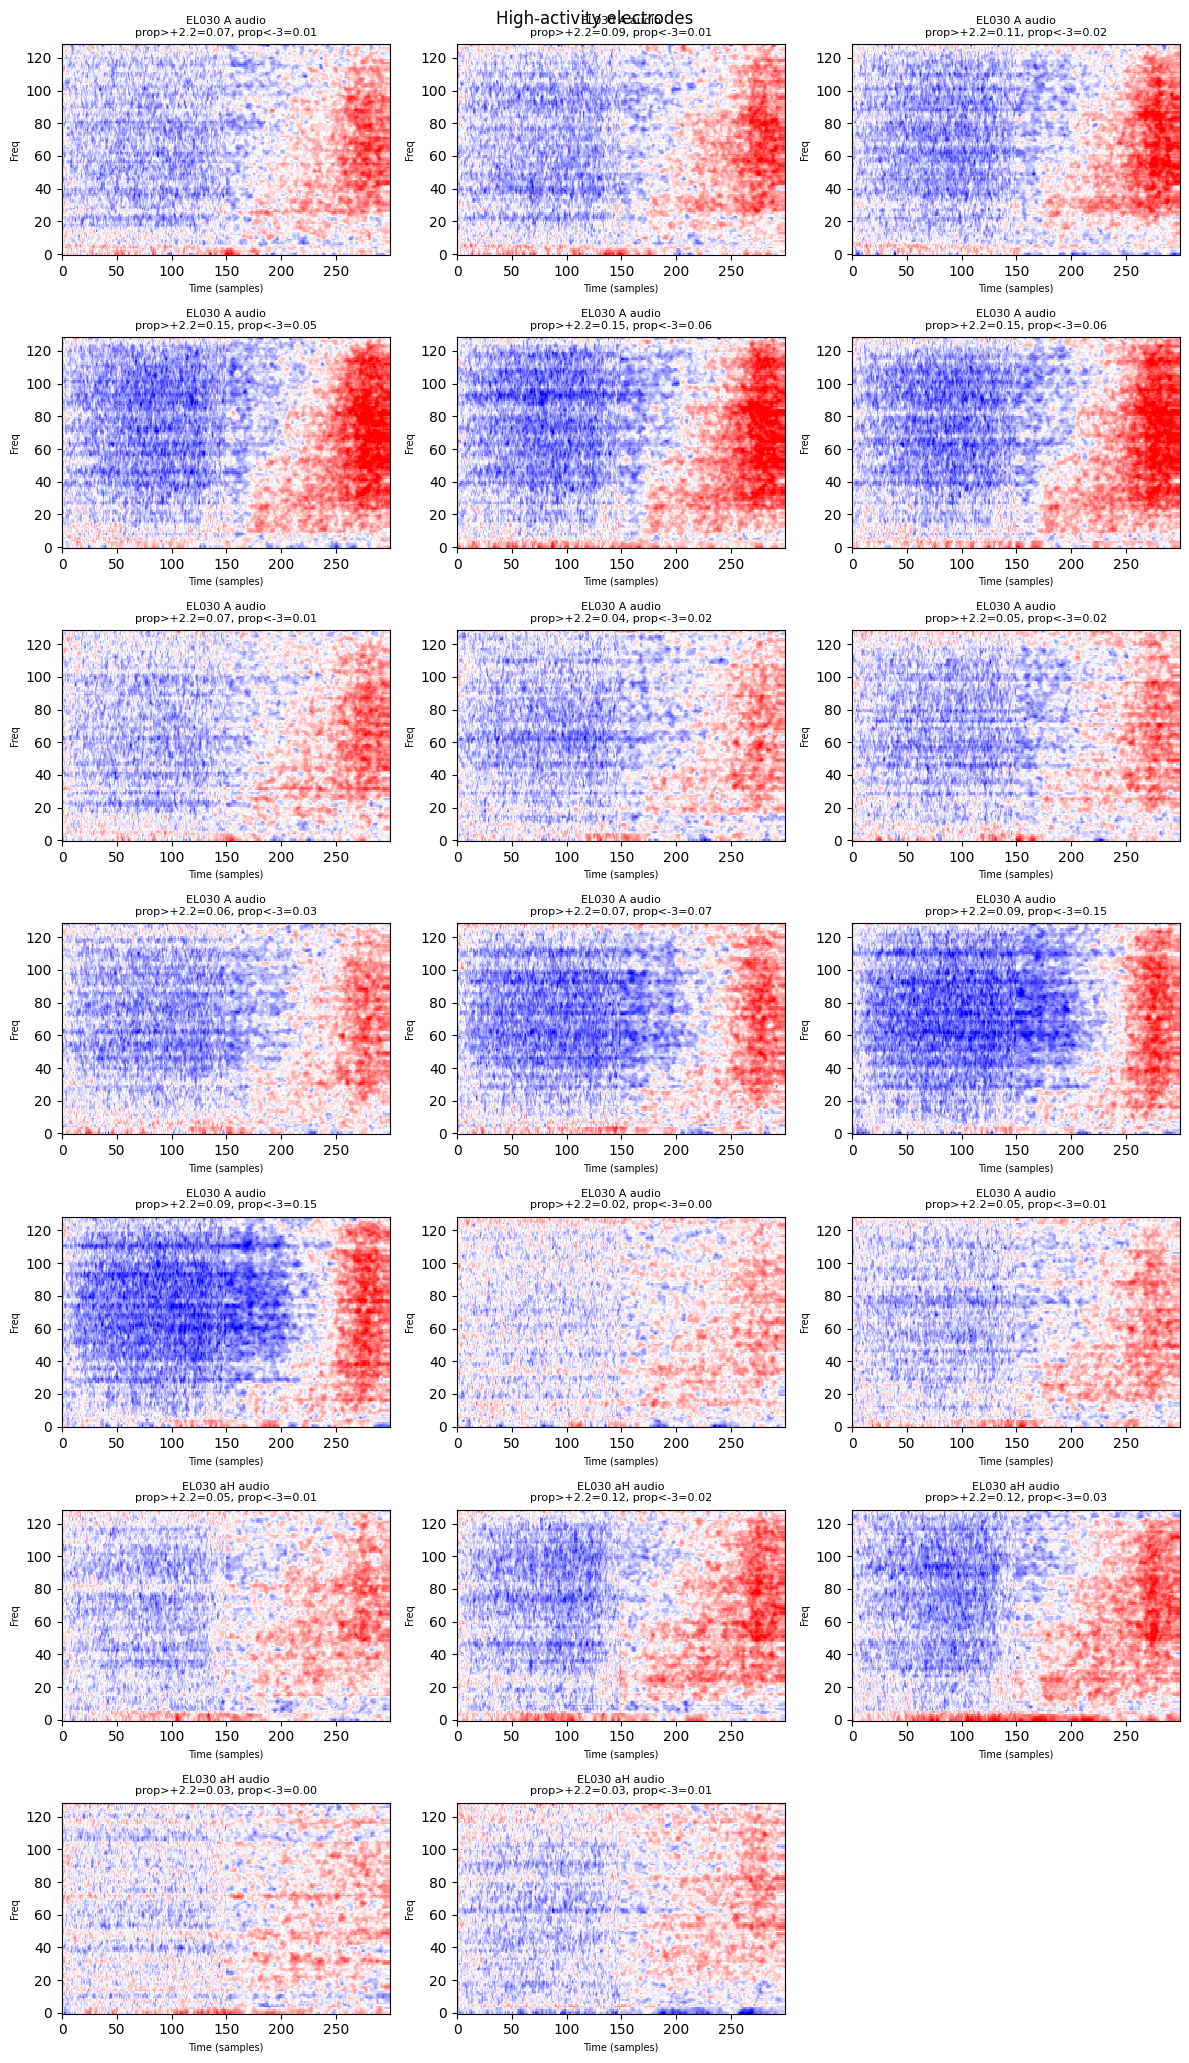

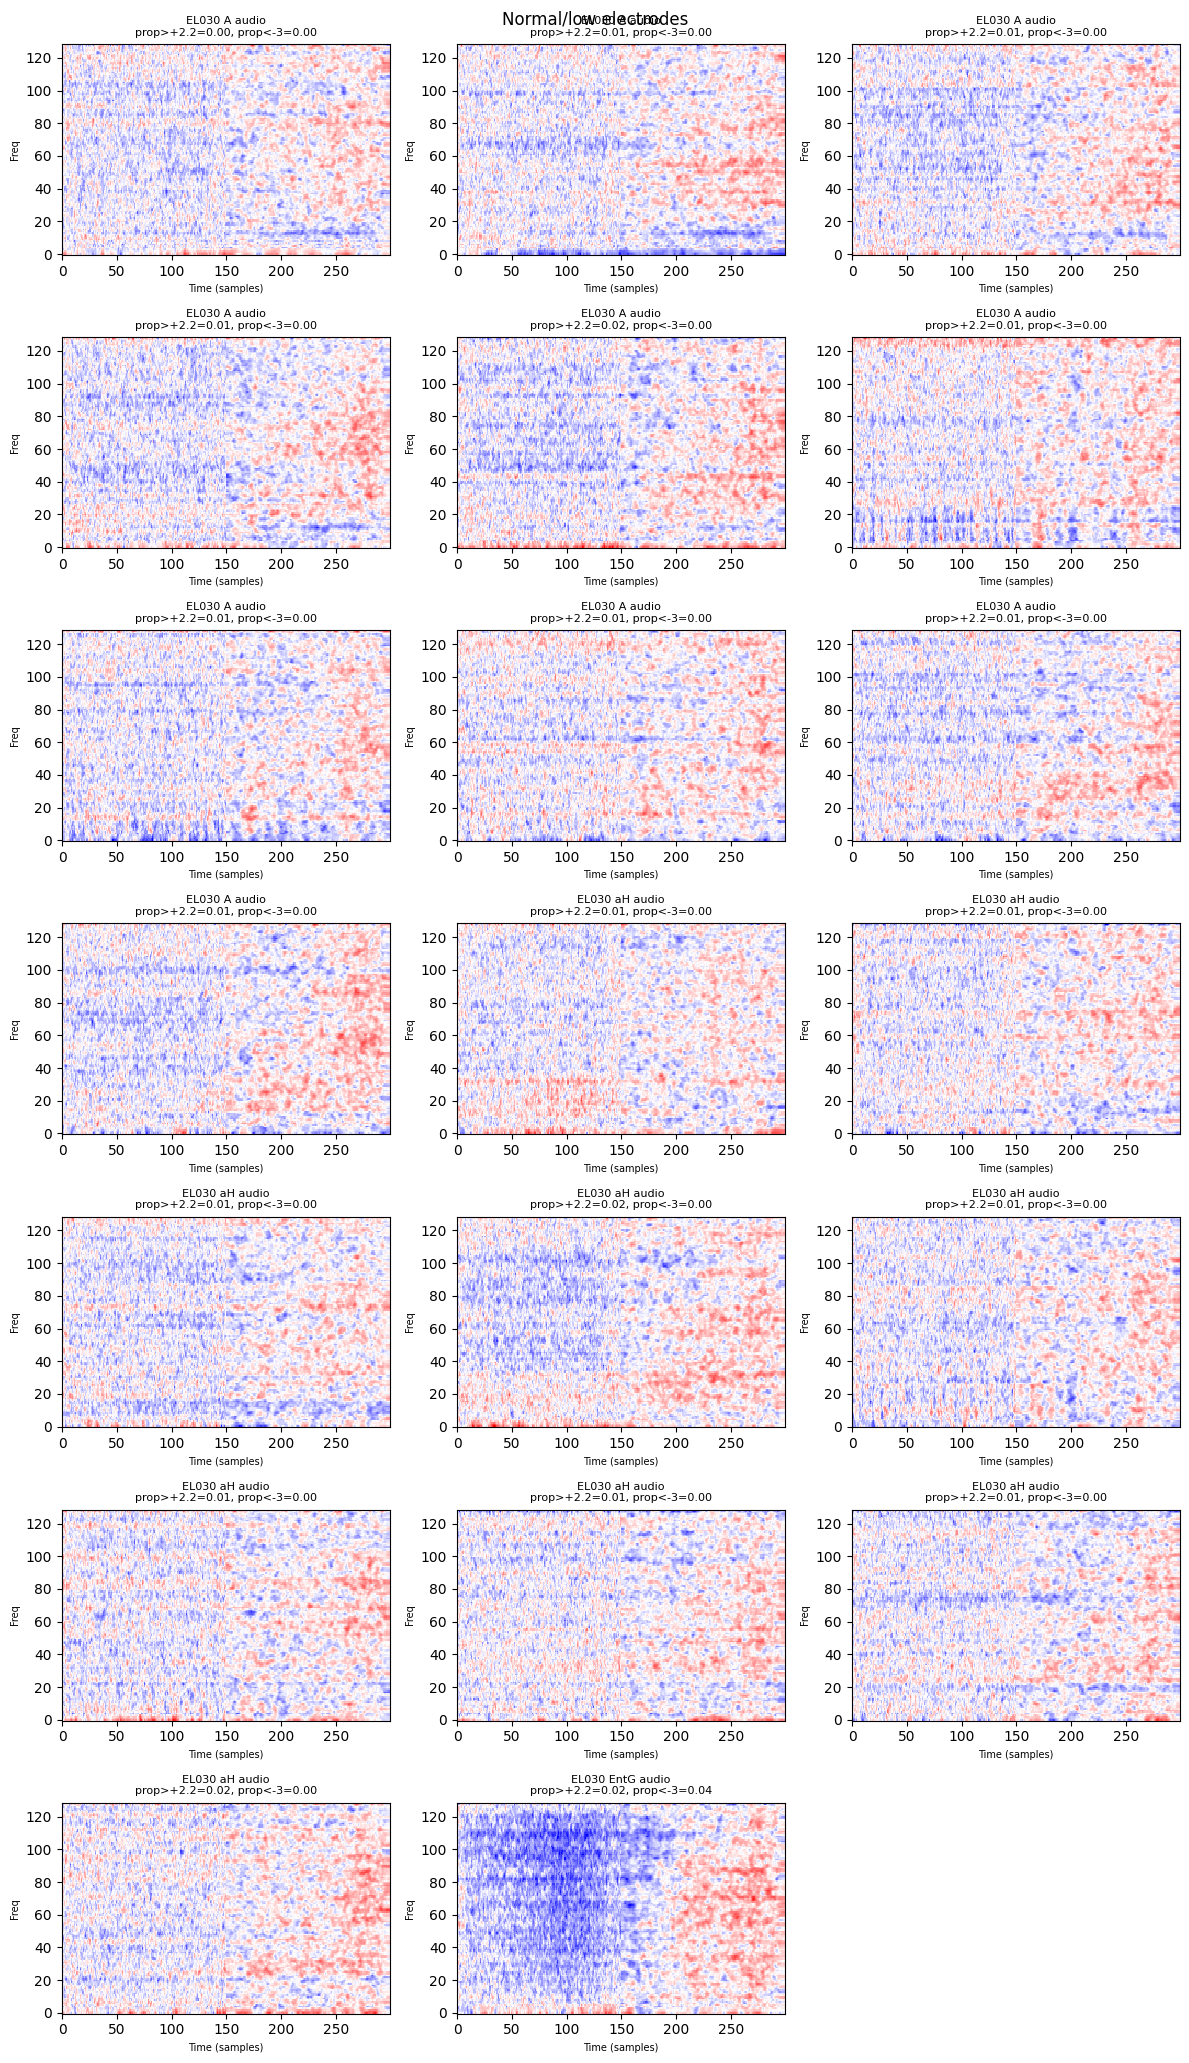

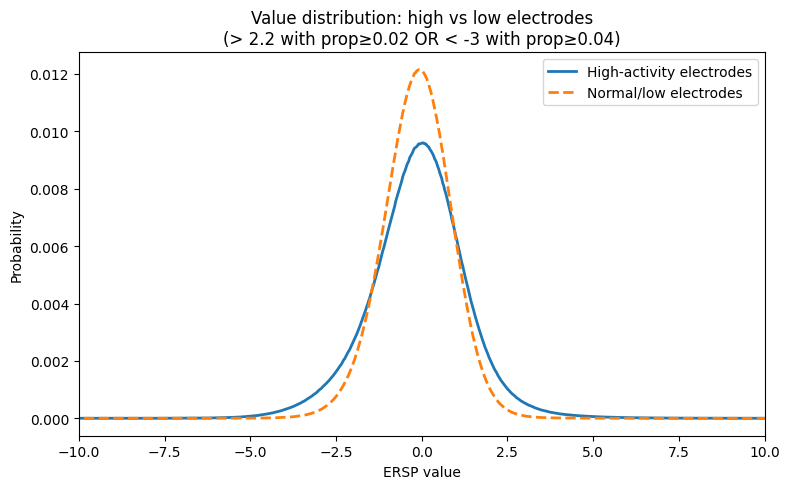

In [5]:
## 4.x High-activity electrode screening & visualization (pos + neg thresholds)

import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
thr_pos = 2.2        # positive threshold
min_prop_pos = 0.02  # min proportion (> thr_pos) to be considered high-positive

thr_neg = -3       # negative threshold
min_prop_neg = 0.04  # min proportion (< thr_neg) to be considered high-negative

max_examples = 20    # how many electrodes to plot from each group
n_bins = 1000        # histogram bins for value distributions

if len(ersp_list) == 0:
    raise RuntimeError("No ERSP data available after exclusions.")

# --- 1) Compute proportions above/below thresholds per electrode ---
prop_pos = []
prop_neg = []
high_flags = []

for arr in ersp_list:
    vals = arr  # shape (N_FREQ, N_TIME)

    mask_pos = vals > thr_pos
    mask_neg = vals < thr_neg

    p_pos = mask_pos.mean()
    p_neg = mask_neg.mean()

    prop_pos.append(p_pos)
    prop_neg.append(p_neg)

    high_flags.append((p_pos >= min_prop_pos) or (p_neg >= min_prop_neg))

df_meta["prop_above_pos"] = prop_pos
df_meta["prop_below_neg"] = prop_neg
df_meta["high_activity"] = high_flags

n_high = df_meta["high_activity"].sum()
n_low  = len(df_meta) - n_high

print(f"Positive threshold: value > {thr_pos}, high if prop ≥ {min_prop_pos:.2f}")
print(f"Negative threshold: value < {thr_neg}, high if prop ≥ {min_prop_neg:.2f}")
print(f"High-activity electrodes: {n_high}")
print(f"Normal/low electrodes:    {n_low}")

# --- 2) Visualize a few ERSPs from each group (high vs low) ---

high_idx = df_meta.index[df_meta["high_activity"]].tolist()
low_idx  = df_meta.index[~df_meta["high_activity"]].tolist()

print("\nExample high-activity electrodes:")
display(
    df_meta.loc[high_idx, ["patient_id", "electrode", "condition",
                           "prop_above_pos", "prop_below_neg"]]
    .sort_values(["prop_above_pos", "prop_below_neg"], ascending=[False, False])
    .head(min(max_examples, len(high_idx)))
)

print("\nExample normal/low electrodes:")
display(
    df_meta.loc[low_idx, ["patient_id", "electrode", "condition",
                          "prop_above_pos", "prop_below_neg"]]
    .sort_values(["prop_above_pos", "prop_below_neg"], ascending=[True, True])
    .head(min(max_examples, len(low_idx)))
)

# Determine common color scale from subset for visualization
all_vals_sample = []
for i in (high_idx[:max_examples] + low_idx[:max_examples]):
    all_vals_sample.append(ersp_list[i].ravel())
if all_vals_sample:
    all_vals_sample = np.concatenate(all_vals_sample)
    v = np.nanmax(np.abs(all_vals_sample))
    vmin, vmax = -v, v
else:
    vmin = vmax = None

def plot_group_examples(indices, title_prefix):
    n = min(max_examples, len(indices))
    if n == 0:
        print(f"No electrodes in group '{title_prefix}', skipping plots.")
        return

    n_cols = 3
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, idx in zip(axes, indices[:n]):
        ersp = ersp_list[idx]
        meta = df_meta.iloc[idx]

        im = ax.imshow(
            ersp,
            aspect="auto",
            origin="lower",
            cmap="bwr",
            vmin=-5,
            vmax=5,
            interpolation="nearest",
        )
        ax.set_title(
            f"{meta['patient_id']} {meta['electrode']} {meta['condition']}\n"
            f"prop>+{thr_pos}={meta['prop_above_pos']:.2f}, "
            f"prop<{thr_neg}={meta['prop_below_neg']:.2f}",
            fontsize=8,
        )
        ax.set_xlabel("Time (samples)", fontsize=7)
        ax.set_ylabel("Freq", fontsize=7)

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(f"{title_prefix} electrodes", fontsize=12)
    plt.tight_layout()
    plt.show()

# Plot examples
plot_group_examples(high_idx, "High-activity")
plot_group_examples(low_idx,  "Normal/low")

# --- 3) Compare value distributions (high vs low) without giant arrays ---

glob_min, glob_max = np.inf, -np.inf
for arr in ersp_list:
    m = np.nanmin(arr)
    M = np.nanmax(arr)
    if m < glob_min:
        glob_min = m
    if M > glob_max:
        glob_max = M

bins = np.linspace(glob_min, glob_max, n_bins + 1)
high_hist = np.zeros(n_bins, dtype=np.float64)
low_hist  = np.zeros(n_bins, dtype=np.float64)

for idx, arr in enumerate(ersp_list):
    vals = arr.ravel()
    h, _ = np.histogram(vals, bins=bins)
    if df_meta.iloc[idx]["high_activity"]:
        high_hist += h
    else:
        low_hist += h

high_hist = high_hist / high_hist.sum() if high_hist.sum() > 0 else high_hist
low_hist  = low_hist  / low_hist.sum()  if low_hist.sum()  > 0 else low_hist

bin_centers = 0.5 * (bins[:-1] + bins[1:])

plt.figure(figsize=(8, 5))
plt.plot(bin_centers, high_hist, label="High-activity electrodes", linewidth=2)
plt.plot(bin_centers, low_hist,  label="Normal/low electrodes", linewidth=2, linestyle="--")
plt.xlabel("ERSP value")
plt.ylabel("Probability")
plt.xlim((-10, 10))
plt.title(
    "Value distribution: high vs low electrodes\n"
    f"(> {thr_pos} with prop≥{min_prop_pos:.2f} OR "
    f"< {thr_neg} with prop≥{min_prop_neg:.2f})"
)
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
## 4.y Filter out low-activity electrodes (keep only high-activity)

if "high_activity" not in df_meta.columns:
    raise RuntimeError("Column 'high_activity' not found. Run the threshold cell first.")

# Determine indices to keep
keep_idx = df_meta.index[df_meta["high_activity"]].tolist()
drop_idx = df_meta.index[~df_meta["high_activity"]].tolist()

print("====== High-Activity Electrode Filtering ======")
print(f"Total electrodes before filtering: {len(df_meta)}")
print(f"High-activity electrodes kept:    {len(keep_idx)}")
print(f"Low-activity electrodes removed:   {len(drop_idx)}")
print("===============================================")



# Apply filtering to df_meta and ersp_list
df_meta = df_meta.loc[keep_idx].reset_index(drop=True)
ersp_list = [ersp_list[i] for i in keep_idx]

print("\nAfter filtering:")
print("  df_meta rows:", len(df_meta))
print("  ersp_list len:", len(ersp_list))

# Optional: rebuild sample_idx if you use it later
df_meta["sample_idx"] = np.arange(len(df_meta))


====== High-Activity Electrode Filtering ======
Total electrodes before filtering: 6097
High-activity electrodes kept:    1410
Low-activity electrodes removed:   4687

After filtering:
  df_meta rows: 1410
  ersp_list len: 1410


X_raw shape for UMAP: (1410, 38700)


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (1410, 2)


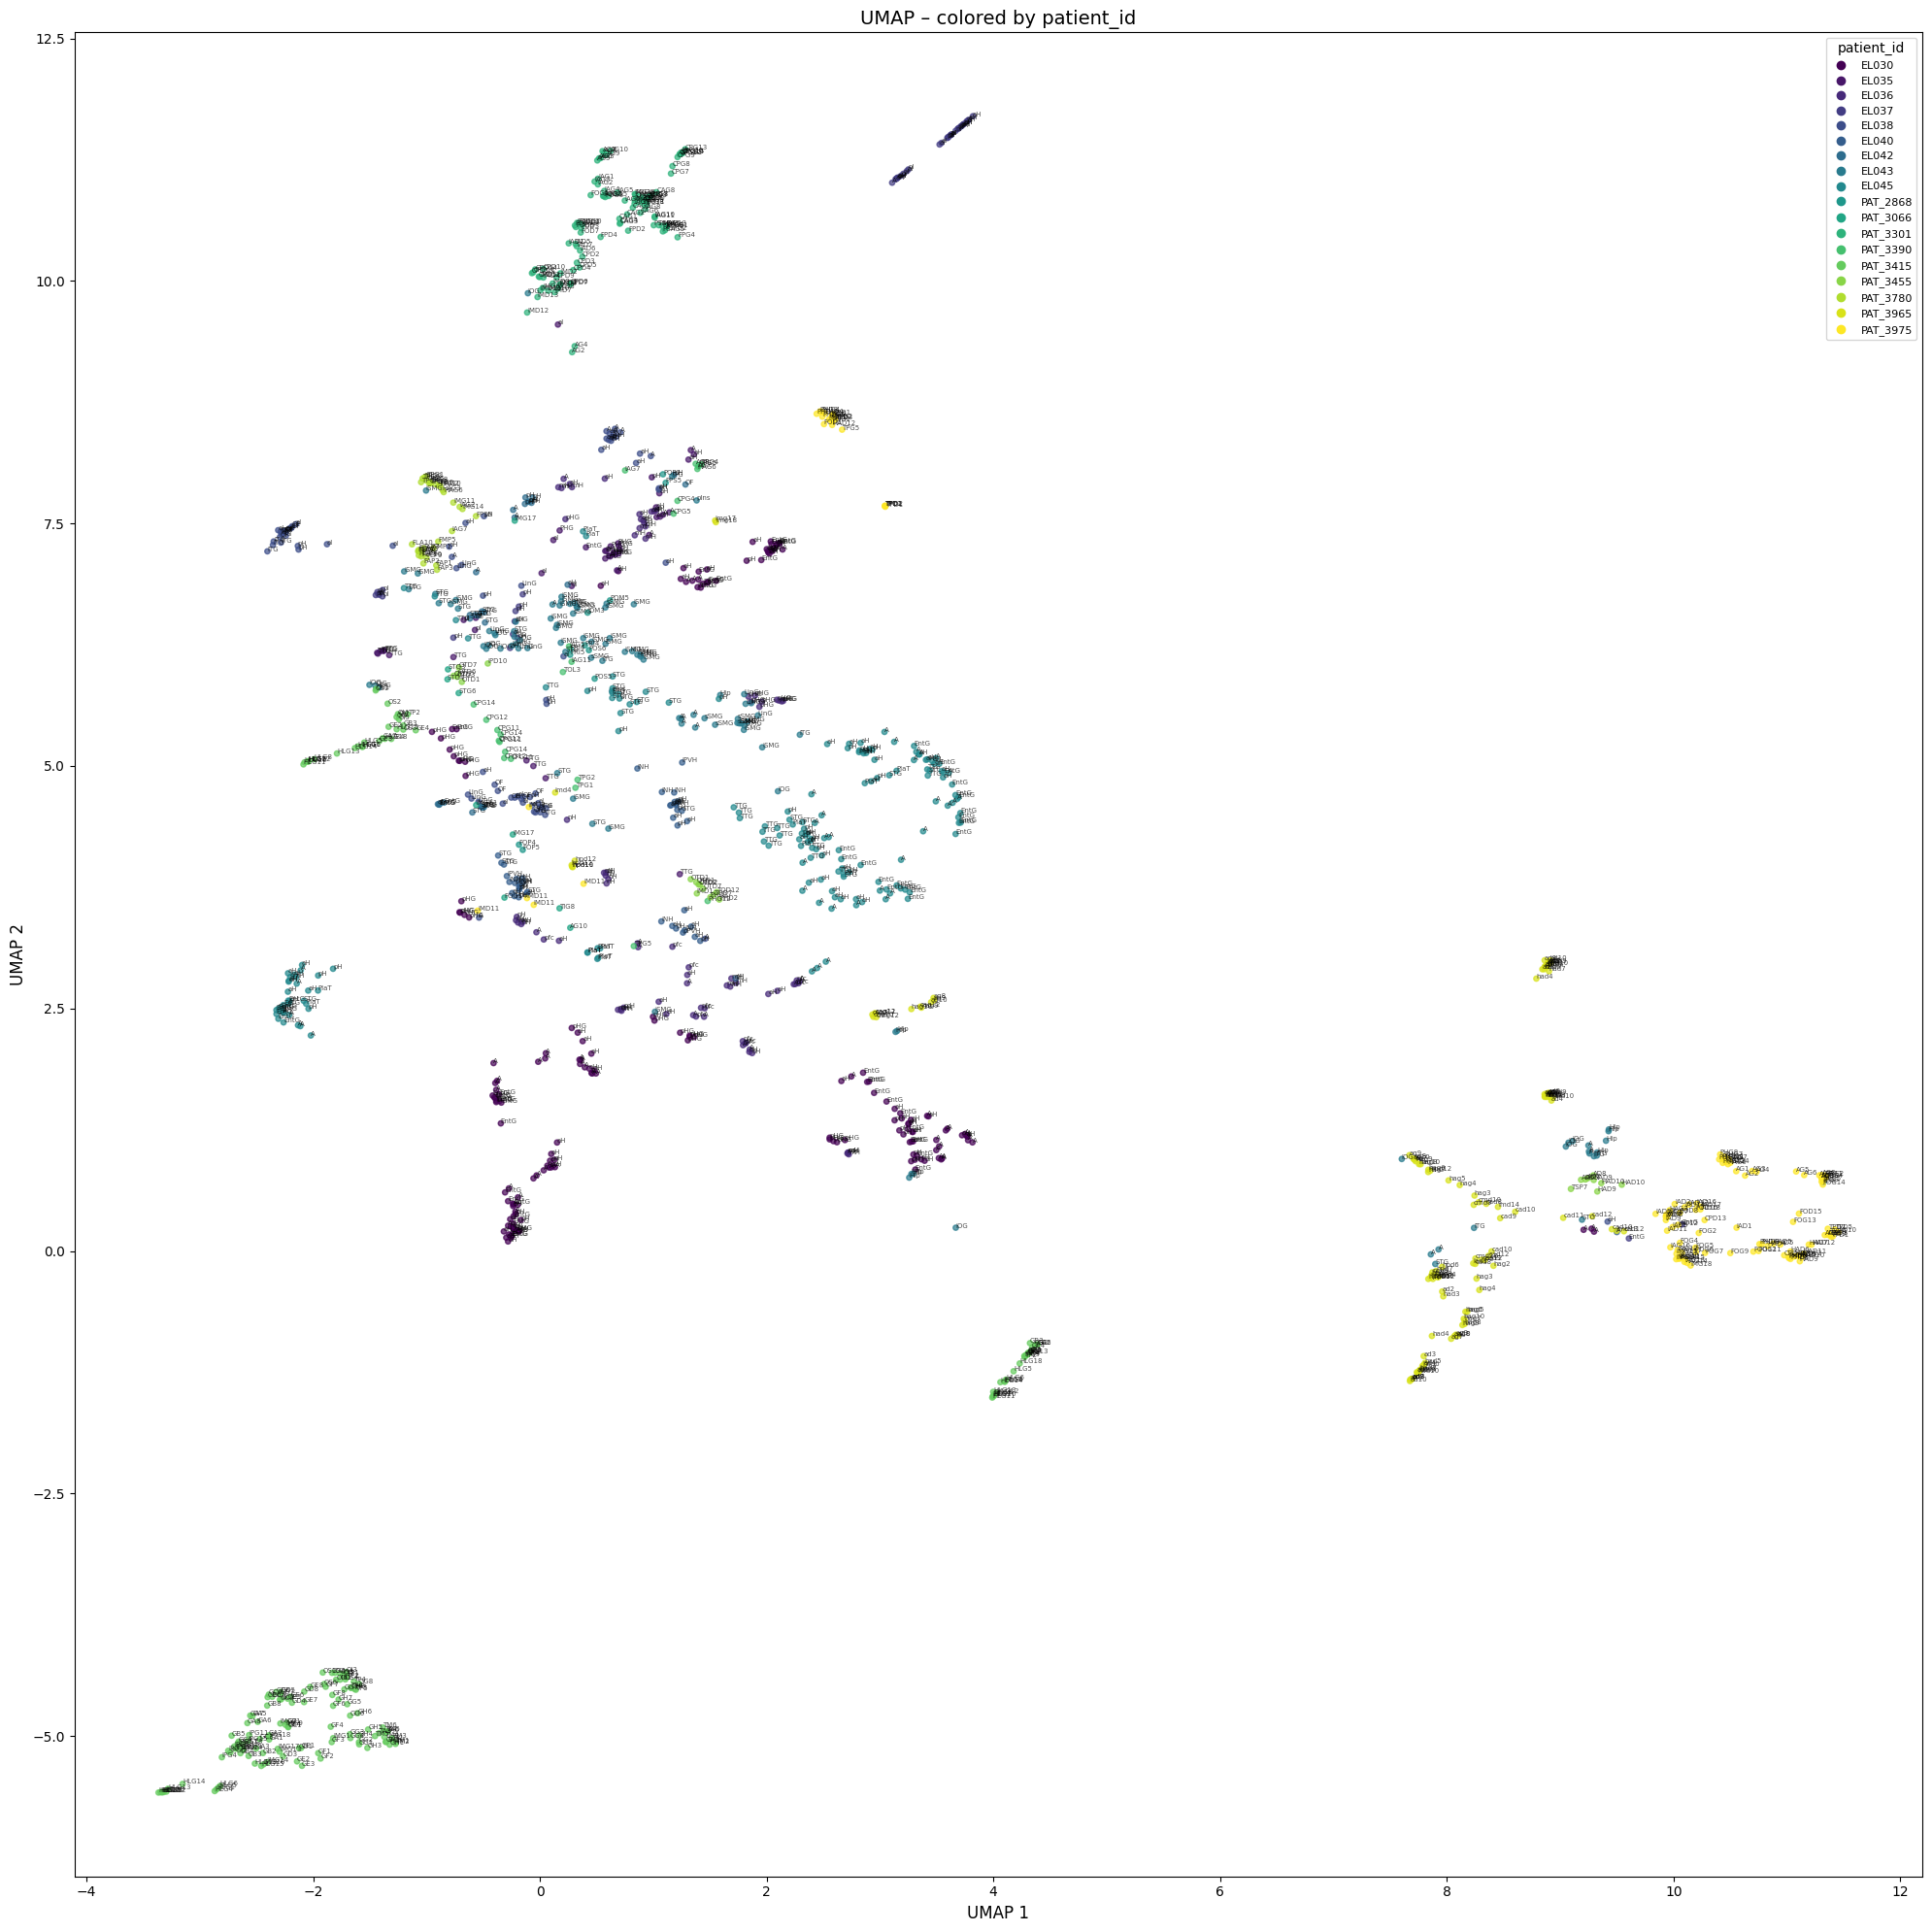

In [7]:
## 3.2. UMAP embedding: inspect all samples 
#                      to decide which ones to remove

import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.utils import validation as skl_validation

# --- Safety checks ---
if len(ersp_list) == 0:
    raise RuntimeError("No ERSP data loaded, cannot run UMAP.")

# Make sure UMAP uses the modern sklearn check_array (fix for ensure_all_finite issue)
umap.umap_.check_array = skl_validation.check_array

# --- In-place NaN fix on ERSPs (freq x time) ---
for arr in ersp_list:
    np.nan_to_num(arr, nan=0.0, copy=False)

# --- Build feature matrix directly: (n_samples, N_FREQ * N_TIME) as float32 ---
n_samples = len(ersp_list)
X_raw = np.empty((n_samples, N_FREQ * N_TIME), dtype=np.float32)

for i, arr in enumerate(ersp_list):
    # arr shape: (N_FREQ, N_TIME) = (129, 300)
    X_raw[i, :] = arr.reshape(-1)

print("X_raw shape for UMAP:", X_raw.shape)

# --- Run UMAP on raw (flattened) data ---
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42,
)

embedding = umap_model.fit_transform(X_raw)
print("UMAP embedding shape:", embedding.shape)

# Attach embedding directly to df_meta (no extra copy)
df_meta["UMAP_1"] = embedding[:, 0]
df_meta["UMAP_2"] = embedding[:, 1]

# --------------------------------------------------------------------
# Plot 1: UMAP colored by patient, with electrode labels
# --------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10*2, 10*2))  # ~4x bigger area than 6x5

patient_codes, patient_uniques = pd.factorize(df_meta["patient_id"])
sc = ax.scatter(
    df_meta["UMAP_1"],
    df_meta["UMAP_2"],
    c=patient_codes,
    s=15,
    alpha=0.7,
)

ax.set_title("UMAP – colored by patient_id", fontsize=14)
ax.set_xlabel("UMAP 1", fontsize=12)
ax.set_ylabel("UMAP 2", fontsize=12)

# Add electrode name as text next to each point
for x, y, label in zip(df_meta["UMAP_1"], df_meta["UMAP_2"], df_meta["electrode"]):
    ax.text(x, y, str(label), fontsize=5, alpha=0.7)

# Legend for patients
handles = []
labels = []
cmap = sc.cmap
norm = plt.Normalize(vmin=patient_codes.min(), vmax=patient_codes.max())

for code, pid in enumerate(patient_uniques):
    handles.append(
        plt.Line2D(
            [], [], marker="o", linestyle="", markersize=6,
            color=cmap(norm(code))
        )
    )
    labels.append(pid)

ax.legend(handles, labels, title="patient_id", fontsize=8, loc="best")
plt.tight_layout()
plt.show()



In [8]:
## 4. Build X_raw (flattened) and standardize

if len(ersp_list) == 0:
    raise RuntimeError("No ERSP data loaded. Check paths and file patterns.")

# Stack into (n_samples, N_TIME, N_FREQ)
X_3d = np.stack(ersp_list, axis=0)  # shape: (n_samples, 300, 128)
print("X_3d shape:", X_3d.shape)

# Flatten each matrix into a single vector (row-major)
X_raw = X_3d.reshape(X_3d.shape[0], -1)  # shape: (n_samples, 38400)
print("X_raw shape:", X_raw.shape)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print("X_scaled shape:", X_scaled.shape)

# Quick sanity check on a subset of features
print("Mean (first 10 features):", X_scaled[:,:10].mean(axis=0))
print("Std  (first 10 features):", X_scaled[:, :10].std(axis=0))


X_3d shape: (1410, 129, 300)
X_raw shape: (1410, 38700)
X_scaled shape: (1410, 38700)
Mean (first 10 features): [ 7.82667863e-17 -9.96051153e-17  1.50391913e-16  1.41730599e-18
  1.76375856e-16  2.30705919e-16  1.42675470e-16 -2.49918289e-16
  2.04643237e-16 -3.01964915e-17]
Std  (first 10 features): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# Clustering

Two methods on the same `X_scaled`: K-Means (with K sweep) and Hierarchical (Ward).
Each `fit_and_save` call writes a self-contained run directory and updates `outputs/clustering/index.json`.


In [17]:
from functions import lf_cluster_run as R

# Sweep K to let silhouette pick the best, but cap to a reasonable range
K_RANGE = [ 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25,26,27,28]

manifest_km = R.fit_and_save(
    X_scaled,
    df_keep=df_meta,
    method='kmeans',
    feature_set='raw',
    params={'k_range': K_RANGE, 'random_state': RANDOM_STATE, 'n_init': 20},
    scaler=scaler,
    method_label='K-Means',
    feature_set_label='Raw ERSP',
    notebook=SCRIPT_NAME,
)
BEST_K = manifest_km['summary']['best_k']
print(f"Best K (KMeans, by silhouette): {BEST_K}")


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


  K=  6  sil=0.0551


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


  K=  7  sil=0.0535


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


...

  K= 27  sil=0.0779


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


  K= 28  sil=0.0778

[KMeans] Best K=27  silhouette=0.0779


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


[fit_and_save] kmeans/raw/20260504_224117
  n_samples=1410 n_clusters=27 silhouette=0.078
  -> 02_FBM_Clustering\outputs\clustering\kmeans\raw\runs\20260504_224117
Best K (KMeans, by silhouette): 27


In [16]:
# Hierarchical (Ward). Use the same K as KMeans best for a fair comparison.
manifest_hc = R.fit_and_save(
    X_scaled,
    df_keep=df_meta,
    method='hierarchical',
    feature_set='raw',
    params={'linkage': 'ward', 'metric': 'euclidean', 'n_clusters': 15},
    scaler=scaler,
    method_label='Hierarchical (Ward)',
    feature_set_label='Raw ERSP',
    notebook=SCRIPT_NAME,
)


[HC] method=ward  metric=euclidean  n=1410  cophenetic_r=0.656


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


[fit_and_save] hierarchical/raw/20260504_224026
  n_samples=1410 n_clusters=15 silhouette=0.057
  -> 02_FBM_Clustering\outputs\clustering\hierarchical\raw\runs\20260504_224026


## ERSP-shaped centroid grids

The orchestrator's `centroids.png` is a generic cluster × feature heatmap. For raw ERSP,
the features have a natural (N_FREQ, N_TIME) shape, so we render a method-specific grid below
for both runs.


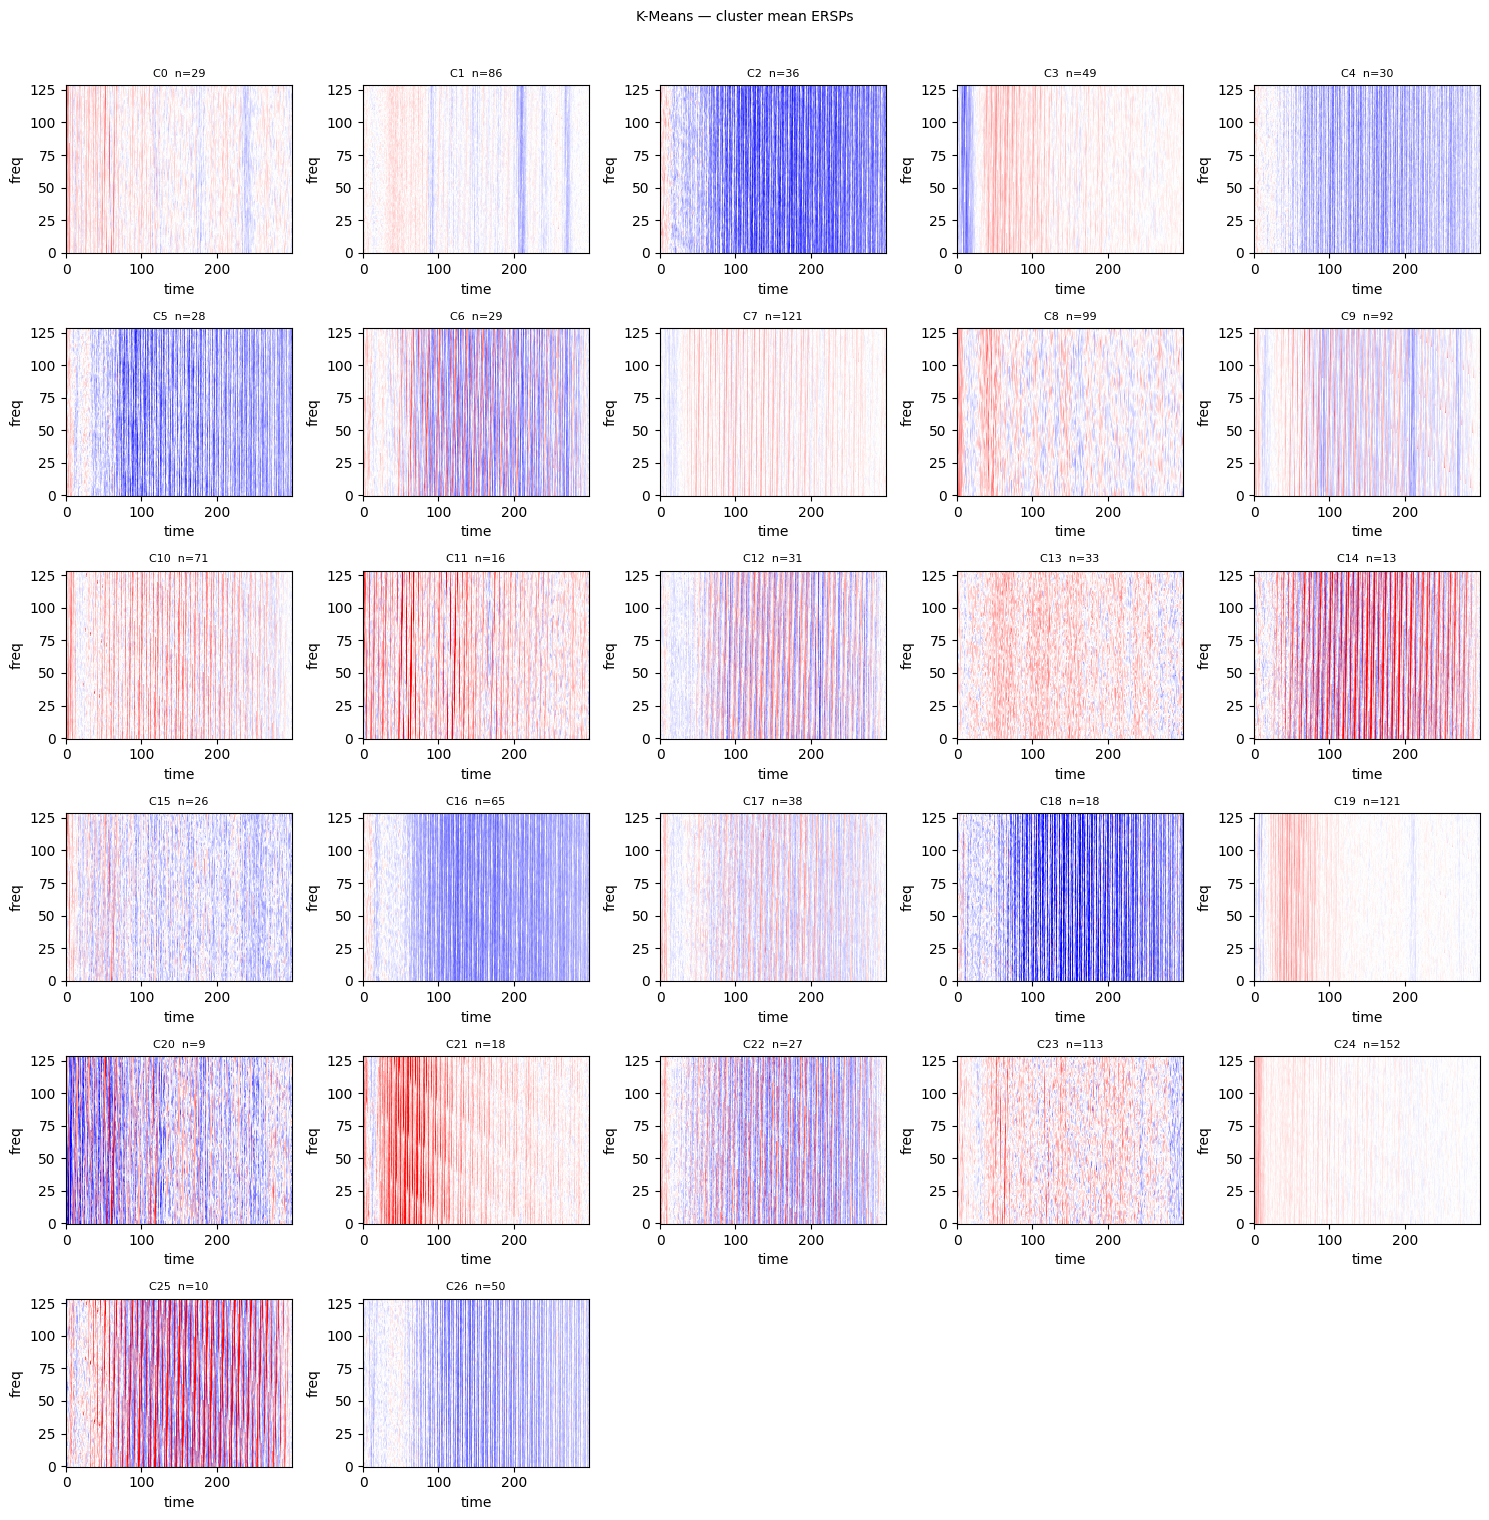

[saved] 02_FBM_Clustering\outputs\clustering\kmeans\raw\runs\20260504_224117\cluster_mean_ersps.png


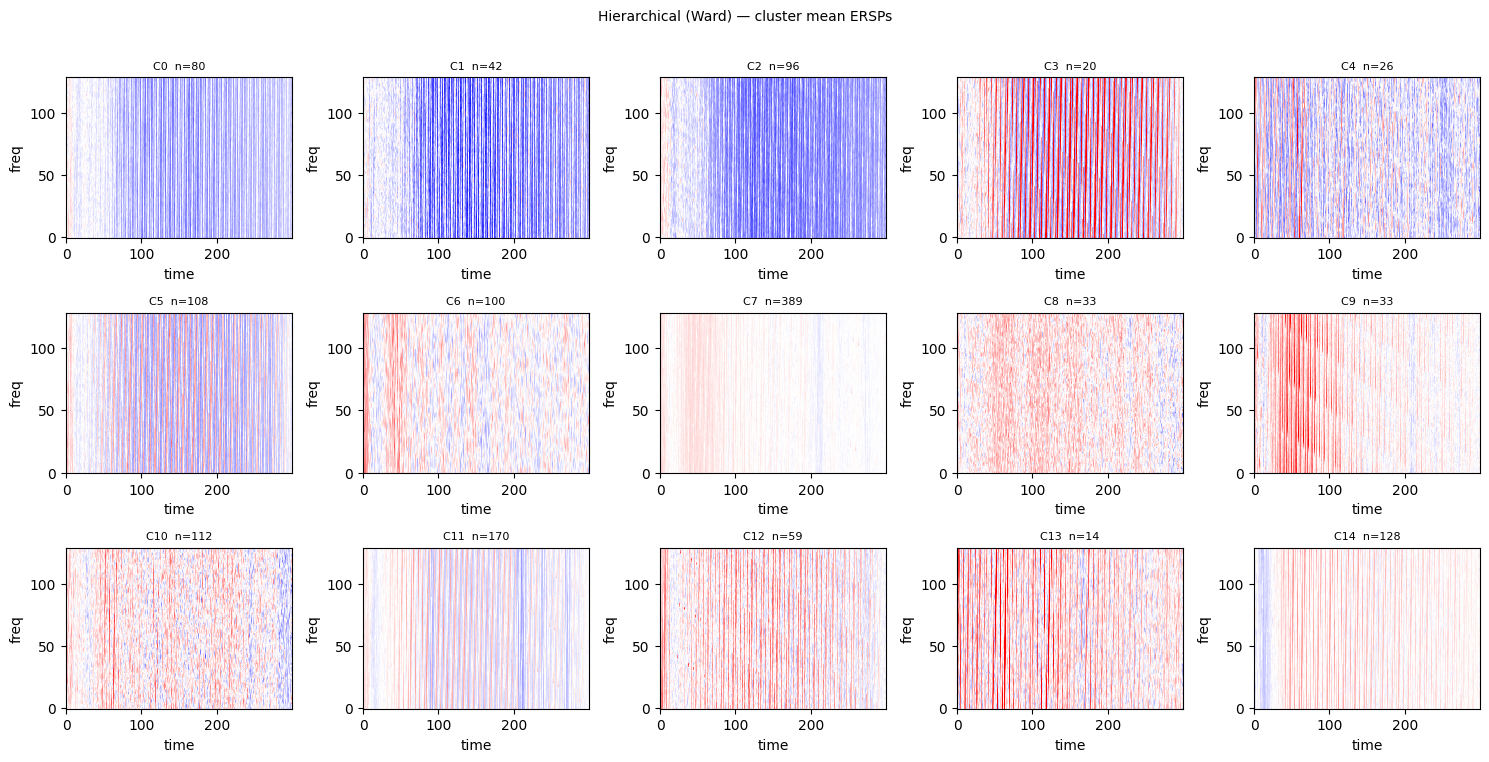

[saved] 02_FBM_Clustering\outputs\clustering\hierarchical\raw\runs\20260504_224026\cluster_mean_ersps.png


In [18]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def _ersp_centroid_grid(manifest, X_3d, *, n_cols=5, vlim=5.0):
    """Reload labels for a saved run, compute per-cluster mean ERSP, plot grid."""
    run_dir = Path('02_FBM_Clustering/outputs/clustering') / manifest['method'] \
        / manifest['feature_set'] / 'runs' / manifest['run_id']
    labels = pd.read_csv(run_dir / 'labels.csv')['cluster'].to_numpy()
    uniq = np.unique(labels)
    k = len(uniq)
    n_rows = int(np.ceil(k / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2.5*n_rows))
    axes = np.atleast_1d(axes).reshape(-1)
    for i, c in enumerate(uniq):
        idx = np.where(labels == c)[0]
        mean_ersp = X_3d[idx].mean(axis=0).reshape(N_TIME, N_FREQ)
        ax = axes[i]
        ax.imshow(mean_ersp.T, aspect='auto', origin='lower',
                  cmap='bwr', vmin=-vlim, vmax=vlim, interpolation='nearest')
        ax.set_title(f'C{c}  n={len(idx)}', fontsize=8)
        ax.set_xlabel('time'); ax.set_ylabel('freq')
    for ax in axes[k:]:
        ax.axis('off')
    plt.suptitle(f"{manifest['method_label']} — cluster mean ERSPs", y=1.01, fontsize=10)
    plt.tight_layout()
    out_path = run_dir / 'cluster_mean_ersps.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'[saved] {out_path}')

_ersp_centroid_grid(manifest_km, X_3d)
_ersp_centroid_grid(manifest_hc, X_3d)


## Inspect cluster cohesion + separation

The orchestrator already saved these figures into each run dir; display them inline for quick comparison.
- **silhouette_per_cluster.png** — which clusters are tight; which are catch-alls.
- **similarity_heatmap.png** — pairwise distance reordered by cluster; tight block-diagonal = good.
- **centroid_distance_heatmap.png** — inter-cluster separation.


In [13]:
# from IPython.display import Image, display, Markdown
# from pathlib import Path

# def _show_run_figures(manifest):
#     run_dir = Path('02_FBM_Clustering/outputs/clustering') / manifest['method'] \
#         / manifest['feature_set'] / 'runs' / manifest['run_id']
#     display(Markdown(f"### {manifest['method_label']} · {manifest['feature_set_label']} · run {manifest['run_id']}"))
#     s = manifest['summary']
#     display(Markdown(
#         f"- n_samples = **{s['n_samples']}**, n_clusters = **{s['n_clusters']}**\n"
#         f"- silhouette = **{s['silhouette_overall']:.3f}**, "
#         f"calinski_harabasz = **{s['calinski_harabasz']:.1f}**, "
#         f"davies_bouldin = **{s['davies_bouldin']:.3f}**\n"
#     ))
#     for name in ['silhouette_per_cluster.png', 'similarity_heatmap.png',
#                  'centroid_distance_heatmap.png']:
#         p = run_dir / name
#         if p.exists():
#             display(Image(filename=str(p)))

# _show_run_figures(manifest_km)
# _show_run_figures(manifest_hc)
